In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from causeinfer.data.hillstrom import load_hillstrom, download_hillstrom
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


/Users/leis/Documents/GitHub/DKRL-LLM/dkrl/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Download the dataset (this will create a 'datasets' folder if it doesn't exist)
print("Downloading Hillstrom dataset...")
download_hillstrom()
print("Dataset downloaded successfully!")


/datasets has been created in your local directory
Attempting to download file to '/Users/leis/Documents/GitHub/DKRL-LLM/Real-Data-with-features/Hillstrom/datasets/hillstrom.csv'...
Download complete
Dataset downloaded successfully!


In [5]:
# Load the dataset with formatting
print("Loading and formatting dataset...")
data = load_hillstrom(format_covariates=True, normalize=True)
print("Dataset loaded successfully!")

# Display dataset description
print("\nDataset Description:")
print(data['description'])


Loading and formatting dataset...
Dataset loaded successfully!

Dataset Description:
The Hillstrom dataset contains 64,000 customers who purchased within twelve months.The customers were involved in an e-mail marketing test.1/3 were randomly chosen to receive an e-mail campaign featuring Mens merchandise.1/3 were randomly chosen to receive an e-mail campaign featuring Womens merchandise.1/3 were randomly chosen to not receive an e-mail campaign.During a period of two weeks following the e-mail campaign, results were tracked.Targeting for causal inference can be derived using visit, conversion, or total spent.


In [6]:
# Create a comprehensive DataFrame for analysis
df = pd.DataFrame(data['dataset_full'], columns=data['dataset_full_names'])

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFeature names: {data['feature_names']}")

# Display first few rows
print("\nFirst 5 rows:")
df.head()


Dataset shape: (64000, 22)

Column names: ['treatment', 'recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_rural', 'zip_code_surburban', 'zip_code_urban', 'history_segment_0_100', 'history_segment_1000+', 'history_segment_100_200', 'history_segment_200_350', 'history_segment_350_500', 'history_segment_500_750', 'history_segment_750_1000', 'channel_multichannel', 'channel_phone', 'spend', 'conversion', 'visit', 'channel_web']

Feature names: ['recency' 'history' 'mens' 'womens' 'newbie' 'zip_code_rural'
 'zip_code_surburban' 'zip_code_urban' 'history_segment_0_100'
 'history_segment_1000+' 'history_segment_100_200'
 'history_segment_200_350' 'history_segment_350_500'
 'history_segment_500_750' 'history_segment_750_1000'
 'channel_multichannel' 'channel_phone' 'channel_web']

First 5 rows:


,treatment,recency,history,mens,womens,newbie,zip_code_rural,zip_code_surburban,zip_code_urban,history_segment_0_100,...,history_segment_200_350,history_segment_350_500,history_segment_500_750,history_segment_750_1000,channel_multichannel,channel_phone,spend,conversion,visit,channel_web
0,2,1.207742,-0.389,1,0,0,False,True,False,False,...,False,False,False,False,False,True,0.0,0,0,False
1,0,0.067358,0.339611,1,1,1,True,False,False,False,...,True,False,False,False,False,False,0.0,0,0,True
2,2,0.352454,-0.239834,0,1,1,False,True,False,False,...,False,False,False,False,False,False,0.0,0,0,True
3,1,0.922646,1.693265,1,0,1,True,False,False,False,...,False,False,True,False,False,False,0.0,0,0,True
4,2,-1.073025,-0.768062,1,0,0,False,False,True,True,...,False,False,False,False,False,False,0.0,0,0,True


In [7]:
# Basic statistics
print("Dataset Info:")
print(df.info())

print("\nBasic Statistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   treatment                 64000 non-null  object
 1   recency                   64000 non-null  object
 2   history                   64000 non-null  object
 3   mens                      64000 non-null  object
 4   womens                    64000 non-null  object
 5   newbie                    64000 non-null  object
 6   zip_code_rural            64000 non-null  object
 7   zip_code_surburban        64000 non-null  object
 8   zip_code_urban            64000 non-null  object
 9   history_segment_0_100     64000 non-null  object
 10  history_segment_1000+     64000 non-null  object
 11  history_segment_100_200   64000 non-null  object
 12  history_segment_200_350   64000 non-null  object
 13  history_segment_350_500   64000 non-null  object
 14  history_

,treatment,recency,history,mens,womens,newbie,zip_code_rural,zip_code_surburban,zip_code_urban,history_segment_0_100,...,history_segment_200_350,history_segment_350_500,history_segment_500_750,history_segment_750_1000,channel_multichannel,channel_phone,spend,conversion,visit,channel_web
count,64000,64000.000000,64000.000000,64000,64000,64000,64000,64000,64000,64000,...,64000,64000,64000,64000,64000,64000,64000.0,64000,64000,64000
unique,3,12.000000,34833.000000,2,2,2,2,2,2,2,...,2,2,2,2,2,2,429.0,2,2,2
top,2,-1.358121,-0.827986,1,1,1,False,False,False,False,...,False,False,False,False,False,False,0.0,0,0,False
freq,21387,8952.000000,7947.000000,35266,35182,32144,54437,35224,38339,41030,...,51711,57591,59089,62141,56238,35979,63422.0,63422,54606,35783


Treatment column: treatment
Loading raw data to get treatment labels...

Raw treatment distribution:
treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Encoded treatment distribution:
treatment
2    21387
1    21307
0    21306
Name: count, dtype: int64


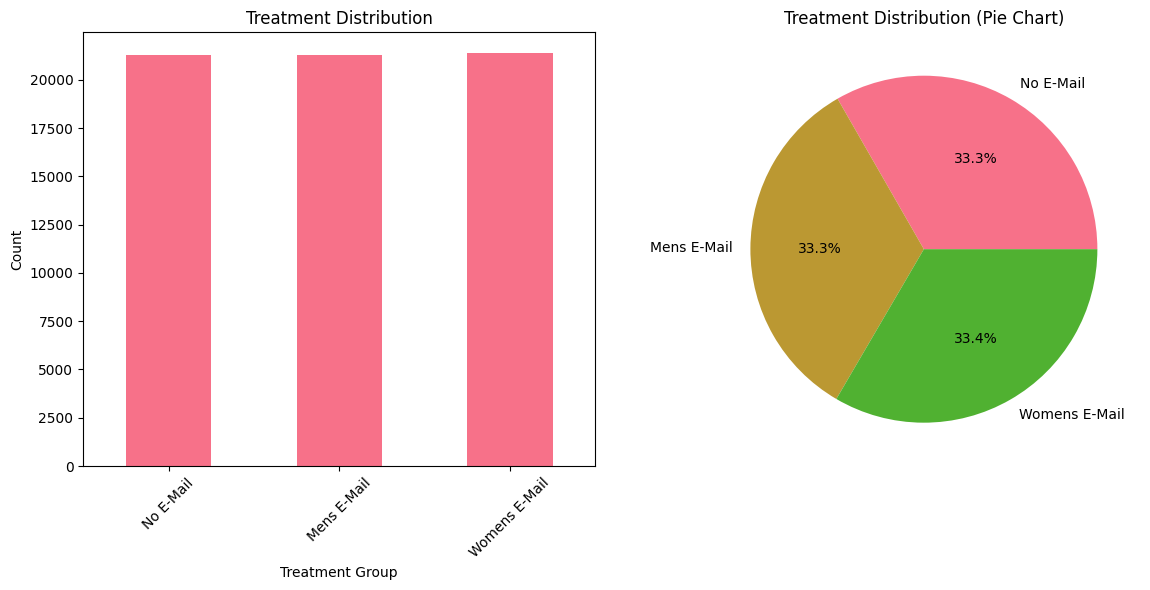

In [8]:
# Analyze treatment distribution
treatment_col = 'treatment'
print(f"Treatment column: {treatment_col}")

# Get raw treatment labels for better understanding
print("Loading raw data to get treatment labels...")
data_raw = load_hillstrom(format_covariates=False, normalize=False)
df_raw = pd.DataFrame(data_raw['dataset_full'], columns=data_raw['dataset_full_names'])
raw_treatment_counts = df_raw[treatment_col].value_counts()
print(f"\nRaw treatment distribution:")
print(raw_treatment_counts)

# For formatted data
treatment_counts = df[treatment_col].value_counts()
print(f"\nEncoded treatment distribution:")
print(treatment_counts)

# Create treatment labels mapping
treatment_labels = {0: 'No E-Mail', 1: 'Mens E-Mail', 2: 'Womens E-Mail'}

# Visualize treatment distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Use treatment labels for better visualization
labeled_counts = pd.Series([treatment_counts[i] for i in [0, 1, 2]], 
                          index=[treatment_labels[i] for i in [0, 1, 2]])
labeled_counts.plot(kind='bar')
plt.title('Treatment Distribution')
plt.xlabel('Treatment Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(labeled_counts.values, labels=labeled_counts.index, autopct='%1.1f%%')
plt.title('Treatment Distribution (Pie Chart)')

plt.tight_layout()
plt.show()


In [ ]:
# Identify outcome columns
outcome_cols = ['spend', 'visit', 'conversion']
actual_outcome_cols = [col for col in outcome_cols if col in df.columns]

if not actual_outcome_cols:
    # Find columns that might be outcomes
    potential_outcomes = [col for col in df.columns if any(word in col.lower() for word in ['spend', 'visit', 'conversion', 'response'])]
    actual_outcome_cols = potential_outcomes

print(f"Outcome columns found: {actual_outcome_cols}")

# Analyze outcomes by treatment
if actual_outcome_cols:
    outcome_summary = df.groupby(treatment_col)[actual_outcome_cols].agg(['mean', 'std', 'count'])
    print("\nOutcome Summary by Treatment:")
    print(outcome_summary)
else:
    print("No standard outcome columns found. Let's examine all columns:")
    print(df.columns.tolist())


In [ ]:
# Visualize outcomes by treatment
if actual_outcome_cols and len(actual_outcome_cols) > 0:
    fig, axes = plt.subplots(1, len(actual_outcome_cols), figsize=(5*len(actual_outcome_cols), 5))
    
    if len(actual_outcome_cols) == 1:
        axes = [axes]
    
    for i, outcome in enumerate(actual_outcome_cols):
        sns.boxplot(data=df, x=treatment_col, y=outcome, ax=axes[i])
        axes[i].set_title(f'{outcome.title()} by Treatment')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Bar plot of means
    outcome_means = df.groupby(treatment_col)[actual_outcome_cols].mean()
    
    fig, axes = plt.subplots(1, len(actual_outcome_cols), figsize=(5*len(actual_outcome_cols), 5))
    if len(actual_outcome_cols) == 1:
        axes = [axes]
    
    for i, outcome in enumerate(actual_outcome_cols):
        outcome_means[outcome].plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Average {outcome.title()} by Treatment')
        axes[i].set_xlabel('Treatment')
        axes[i].set_ylabel(f'Average {outcome.title()}')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
